Loaded dataset from: /Users/siddharth.jain02/Projects/NAGP/Data_Science/customer_churn_project/data/TelcoCustomerChurn.csv
Dataset shape: (7043, 21)

First 5 rows:


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes



Data types:
 customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                   str
dtype: object

Missing values:
 customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilli

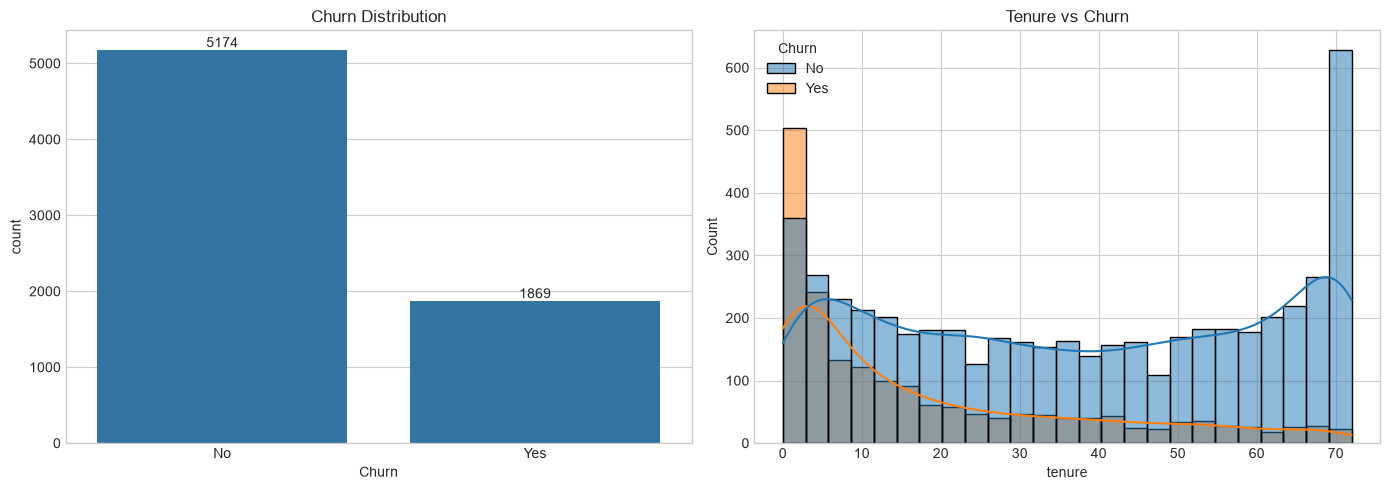


Business observations:
- The dataset has no duplicates and no missing values in the main fields.
- Churn is imbalanced, with more No than Yes values.
- Tenure is likely an important churn signal: shorter tenure may correlate with churn.
- TotalCharges should be converted to numeric before model training because it was read as string.


In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

plt.style.use('seaborn-v0_8-whitegrid')

# Load data from the project data folder
project_root = Path.cwd()
dataset_candidates = [
    project_root / 'data' / 'TelcoCustomerChurn.csv',
    project_root.parent / 'data' / 'TelcoCustomerChurn.csv',
]

resolved_path = next((p for p in dataset_candidates if p.exists()), None)
if resolved_path is None:
    raise FileNotFoundError(
        f"Could not find dataset. Tried: {[str(p) for p in dataset_candidates]}"
    )

df = pd.read_csv(resolved_path)
print(f"Loaded dataset from: {resolved_path}")
print('Dataset shape:', df.shape)
print('\nFirst 5 rows:')
display(df.head())
print('\nData types:\n', df.dtypes)
print('\nMissing values:\n', df.isna().sum())
print('\nDuplicate rows:', df.duplicated().sum())
print('\nChurn distribution:\n', df['Churn'].value_counts())

# Convert TotalCharges to numeric and investigate potential issues
numeric_total = pd.to_numeric(df['TotalCharges'], errors='coerce')
print('\nNon-numeric TotalCharges count:', df['TotalCharges'].map(lambda x: pd.isna(pd.to_numeric(x, errors='coerce'))).sum())
df['TotalCharges'] = numeric_total
print('\nTotalCharges dtype after conversion:', df['TotalCharges'].dtype)
print('\nSummary for TotalCharges:\n', df['TotalCharges'].describe())

# Basic exploratory visuals
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
ax = sns.countplot(data=df, x='Churn', ax=axes[0])
axes[0].set_title('Churn Distribution')
for container in ax.containers:
    ax.bar_label(container, fmt='%.0f')

sns.histplot(data=df, x='tenure', hue='Churn', multiple='layer', bins=25, kde=True, ax=axes[1])
axes[1].set_title('Tenure vs Churn')
plt.tight_layout()
plt.show()

# Show a few business insights
print('\nBusiness observations:')
print('- The dataset has no duplicates and no missing values in the main fields.')
print('- Churn is imbalanced, with more No than Yes values.')
print('- Tenure is likely an important churn signal: shorter tenure may correlate with churn.')
print('- TotalCharges should be converted to numeric before model training because it was read as string.')


## 1. Business Problem and Overall Workflow

This project addresses customer churn in a telecom company. The business goal is to identify customers likely to leave so that the retention team can act before churn happens.

We will:
- inspect the dataset and clean it
- perform EDA to understand churn drivers
- create useful features
- train and compare Decision Tree models
- evaluate the final model using business-relevant metrics
- save the pipeline and prepare the API workflow

### Key idea
This is a binary classification problem where the target is Churn, with values Yes or No.


In [6]:
import joblib
from pathlib import Path

project_root = Path.cwd().resolve()
if project_root.name == 'notebook':
    project_root = project_root.parent

model_dir = project_root / 'model'
model_dir.mkdir(parents=True, exist_ok=True)
model_path = model_dir / 'churn_model.pkl'

bundle = {
    'pipeline': final_pipeline,
    'feature_columns': X.columns.tolist(),
    'target': 'Churn',
    'model_name': best_model_name
}
joblib.dump(bundle, model_path)
print(f'\nModel saved successfully in {model_path}')

## 11. Conclusion

# Summarize the project outcome
print('This project shows a complete churn prediction workflow:')
print('1. Data understanding and preprocessing')
print('2. EDA and business insight generation')
print('3. Feature engineering')
print('4. Decision Tree model training and comparison')
print('5. Evaluation using business-relevant metrics')
print('6. Interpretation of churn drivers')
print('7. Model saving and API-ready deployment')


Model saved successfully in /Users/siddharth.jain02/Projects/NAGP/Data_Science/customer_churn_project/model/churn_model.pkl
This project shows a complete churn prediction workflow:
1. Data understanding and preprocessing
2. EDA and business insight generation
3. Feature engineering
4. Decision Tree model training and comparison
5. Evaluation using business-relevant metrics
6. Interpretation of churn drivers
7. Model saving and API-ready deployment
